<a href="https://colab.research.google.com/github/NguyenQuan297/CS4410_Assignment_Troy_2026Spring/blob/main/ExtraCredit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Set up libraries

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from PIL import Image
import requests
import matplotlib.pyplot as plt
import json

## Load pretrained model (ResNet50)

In [2]:
model = models.resnet50(pretrained=True)
model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 115MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## Image preprocessing

In [3]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

## Load ImageNet labels

In [4]:
LABELS_URL = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
labels = requests.get(LABELS_URL).text.split("\n")

## Show Top-5 predictions function

In [5]:
def predict_image(img_url):

    img = Image.open(requests.get(img_url, stream=True).raw).convert("RGB")

    input_tensor = transform(img)
    input_batch = input_tensor.unsqueeze(0)

    with torch.no_grad():
        output = model(input_batch)

    probabilities = torch.nn.functional.softmax(output[0], dim=0)

    top5_prob, top5_catid = torch.topk(probabilities, 5)

    plt.imshow(img)
    plt.axis("off")
    plt.show()

    print("Top 5 Predictions:")
    for i in range(top5_prob.size(0)):
        print(f"{labels[top5_catid[i]]}: {top5_prob[i].item()*100:.2f}%")

### Image 1: sport car

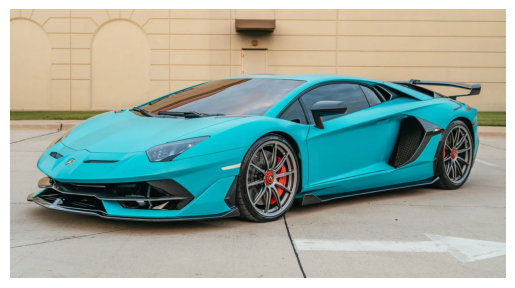

Top 5 Predictions:
sports car: 85.01%
car wheel: 7.42%
racer: 5.56%
beach wagon: 1.00%
convertible: 0.45%


In [17]:
predict_image("https://www.carscoops.com/wp-content/uploads/2022/10/Lamborghini-Aventador-SVJ-a.jpg")

### Image 2: panda

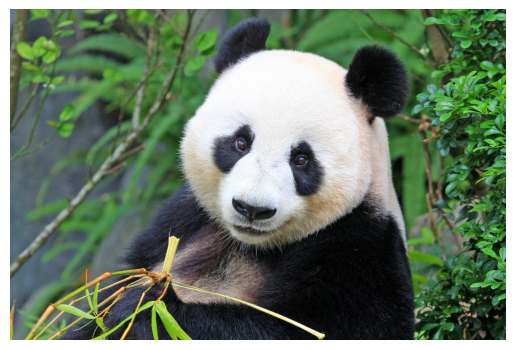

Top 5 Predictions:
giant panda: 99.64%
lesser panda: 0.23%
American black bear: 0.02%
sloth bear: 0.01%
indri: 0.01%


In [11]:
predict_image("https://getwallpapers.com/wallpaper/full/6/a/e/768271-popular-panda-bear-background-2500x1667-cell-phone.jpg")

### Image 3: airplane

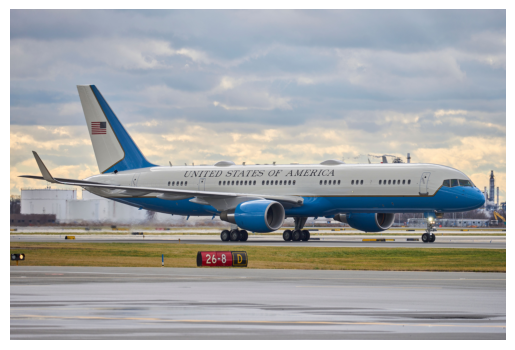

Top 5 Predictions:
airliner: 98.76%
wing: 1.08%
warplane: 0.08%
space shuttle: 0.06%
airship: 0.00%


In [14]:
predict_image("https://static1.simpleflyingimages.com/wordpress/wp-content/uploads/2024/08/shutterstock_2399553061.jpg")